**Multiestabilidad-biestabilidad**

La biestabilidad se refiere a la capacidad de un sistema para tener dos estados estables bajo las mismas condiciones de parámetros. En biología de sistemas, esto significa que, dependiendo de las condiciones iniciales o estímulos externos, el sistema puede asentarse en uno de dos estados de equilibrio. Esto es especialmente relevante en procesos celulares como la diferenciación, donde una célula puede comprometerse hacia dos destinos distintos, o en circuitos de conmutadores genéticos (toggle switches).

La biestabilidad generalmente surge de mecanismos de realimentación positiva, donde una vez que el sistema se aproxima a uno de los estados, esa configuración se refuerza, haciendo que el sistema sea resistente a pequeños cambios. Para transitar de un estado a otro, se requiere una perturbación significativa, lo que da lugar a comportamientos de histéresis y conmutación abrupta entre estados.

-------------------------------------------------------------------------------
phaseR: Phase plane analysis of one- and two-dimensional autonomous ODE systems
-------------------------------------------------------------------------------

v.2.1: For an overview of the package's functionality enter: ?phaseR

For news on the latest updates enter: news(package = "phaseR")



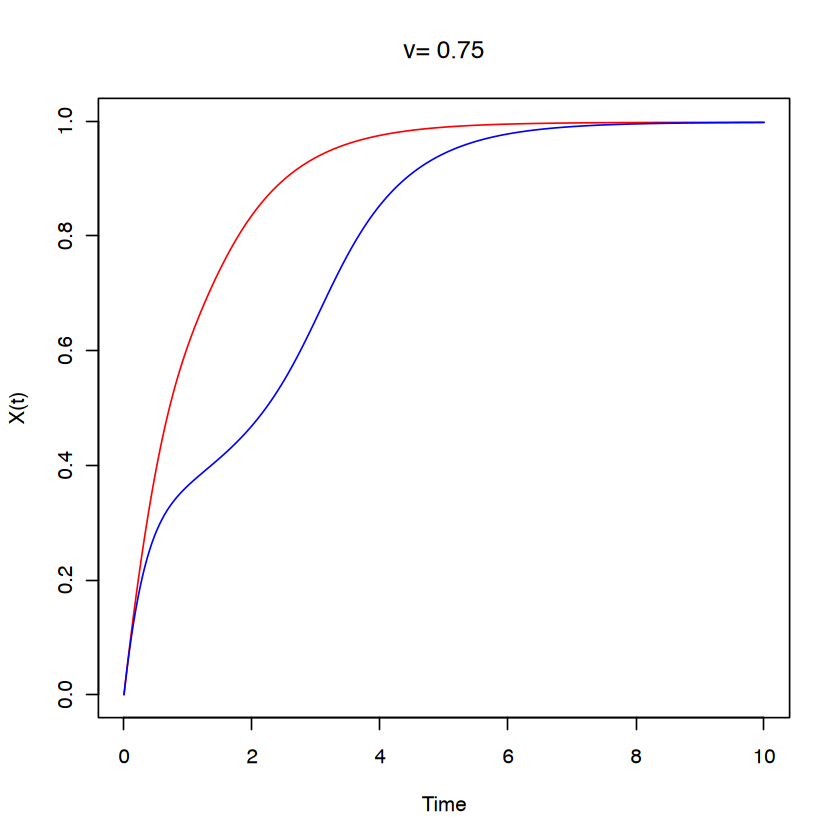

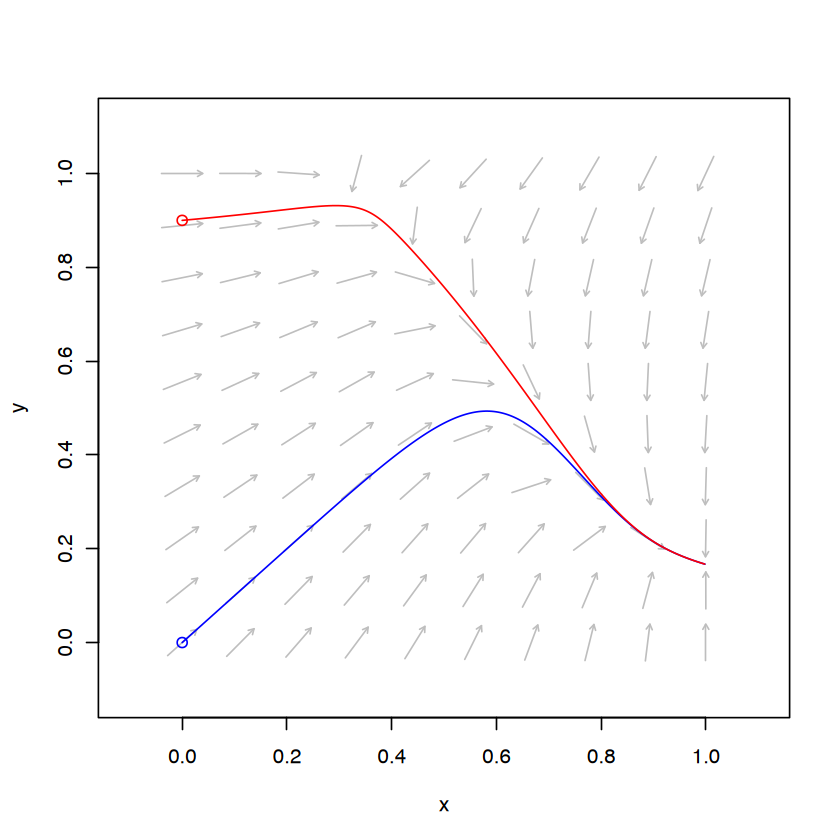

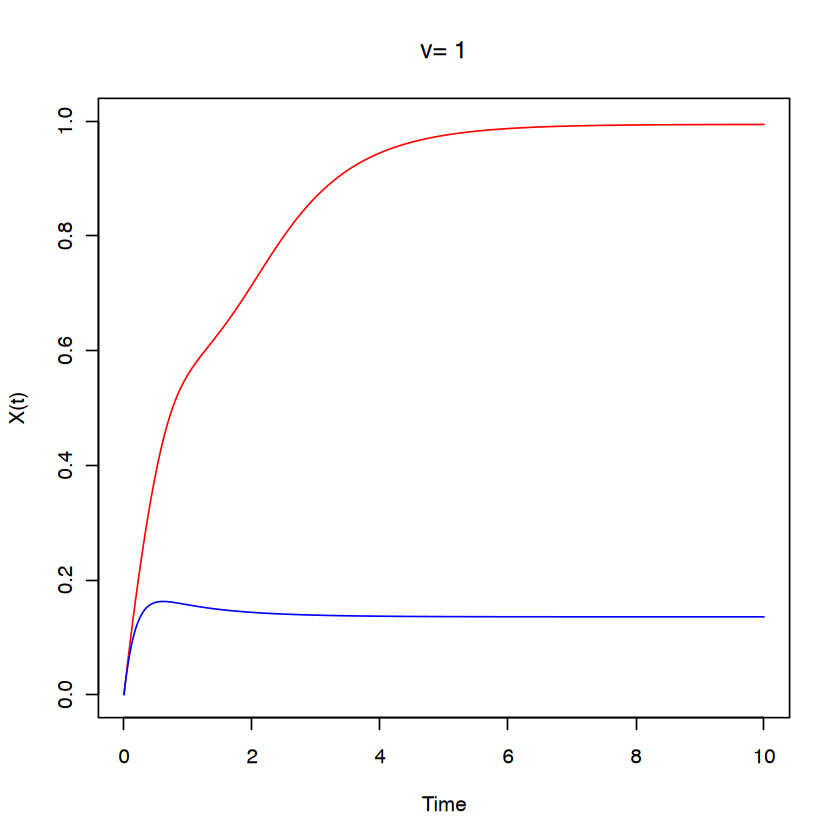

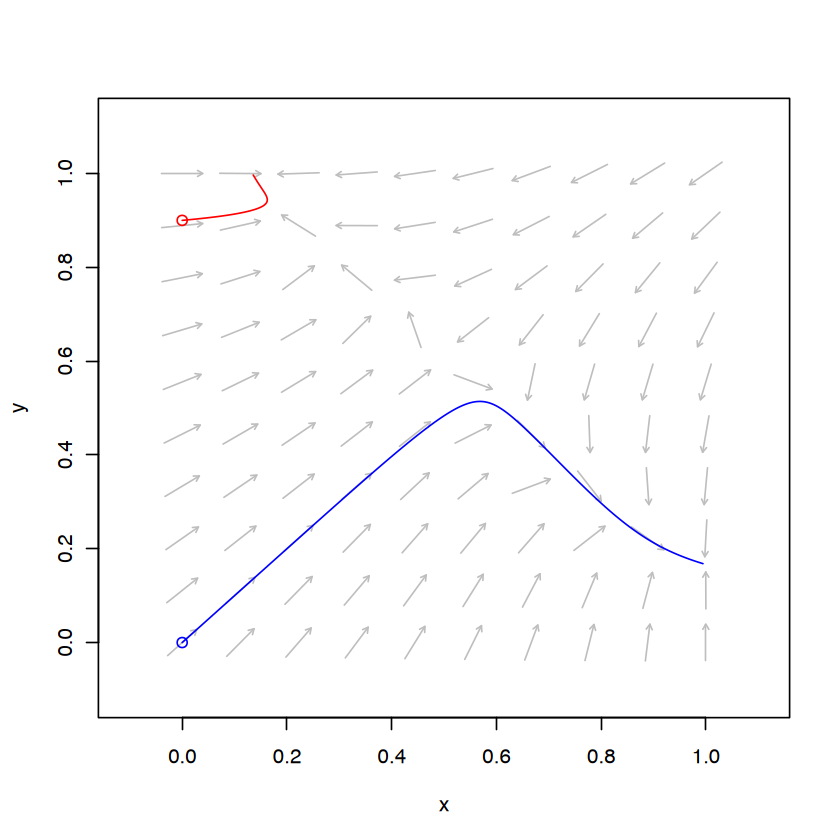

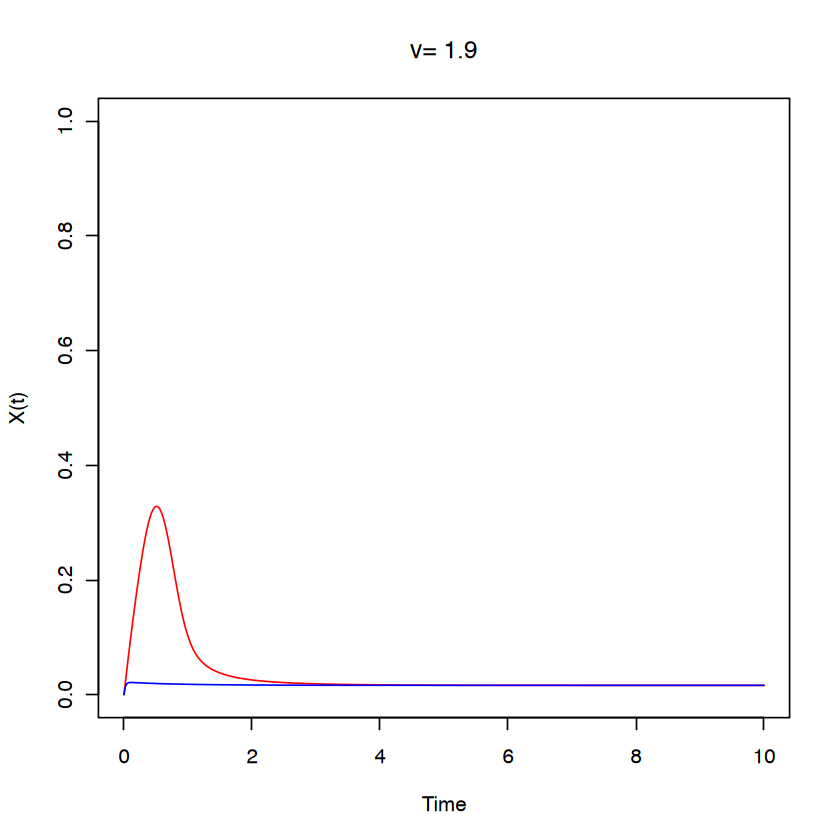

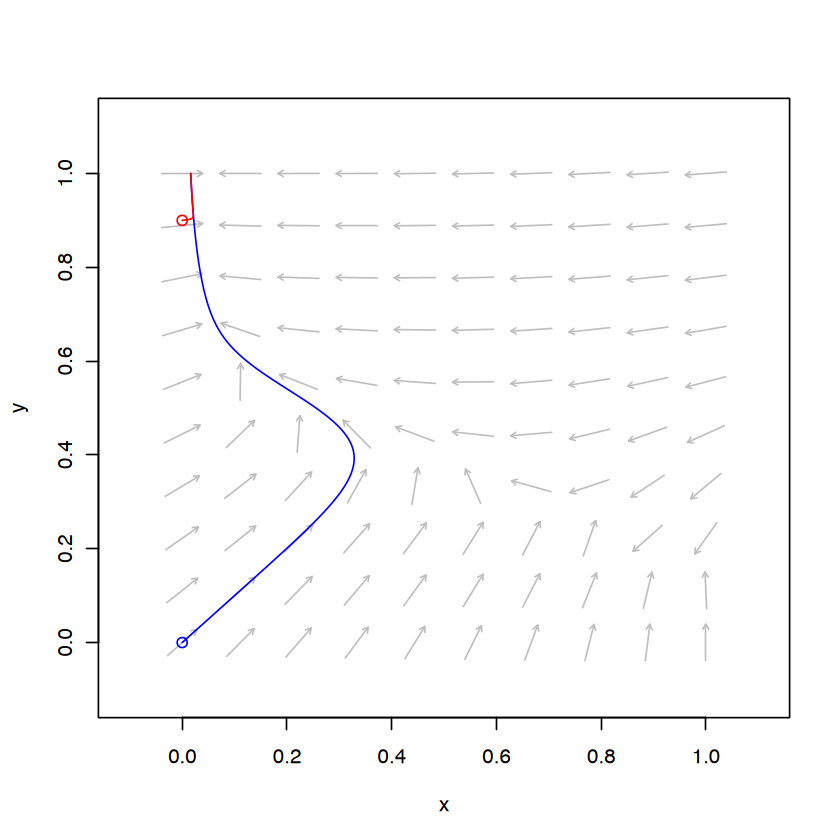

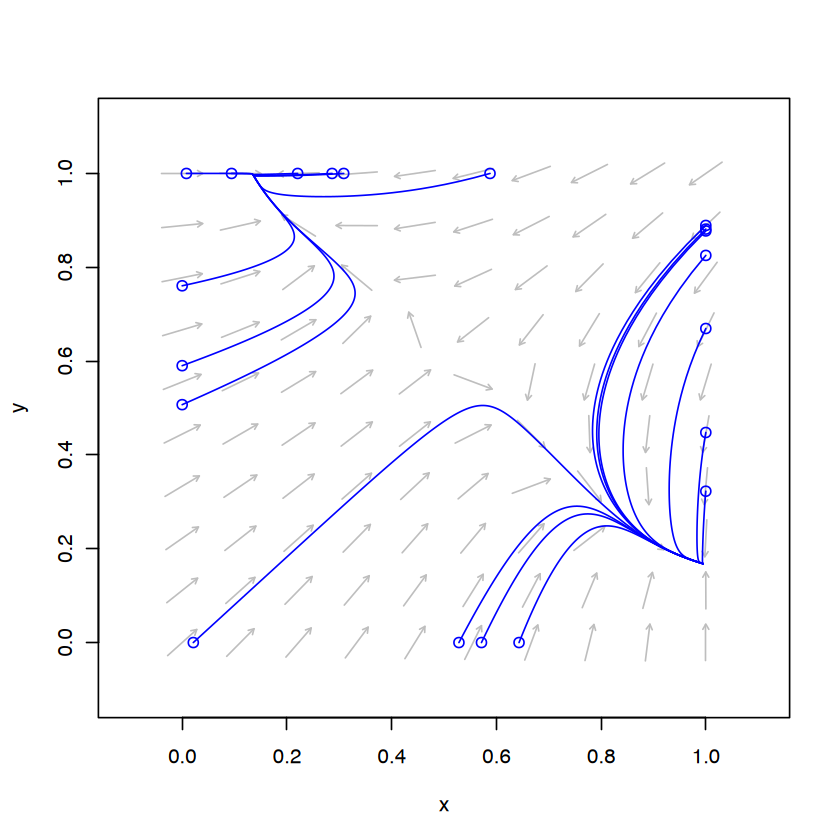

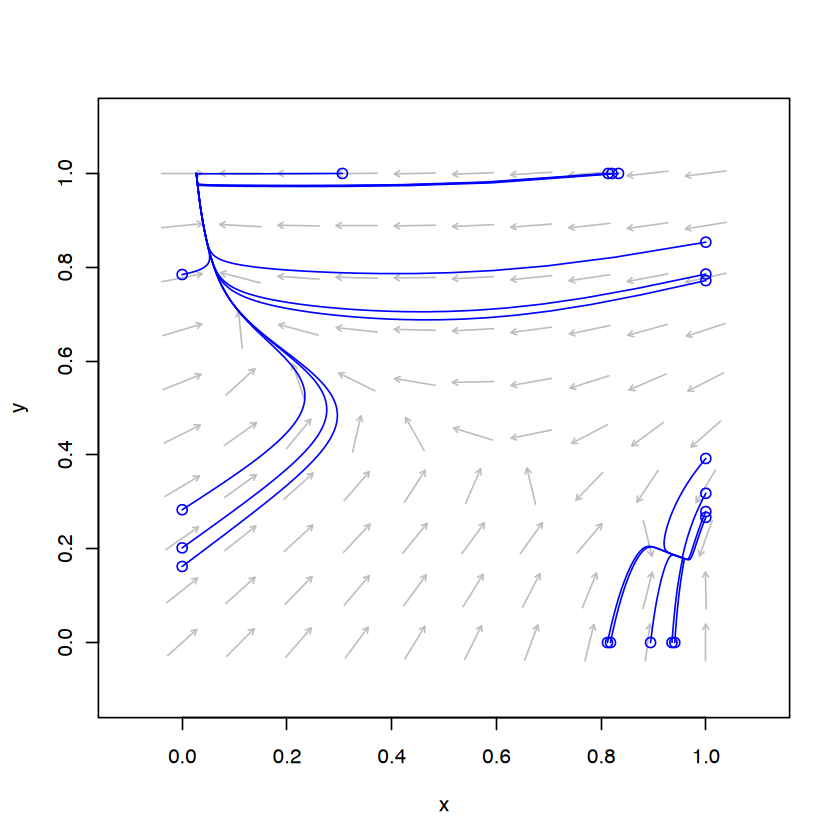

Cargando paquete requerido: coda



grind.R was sourced


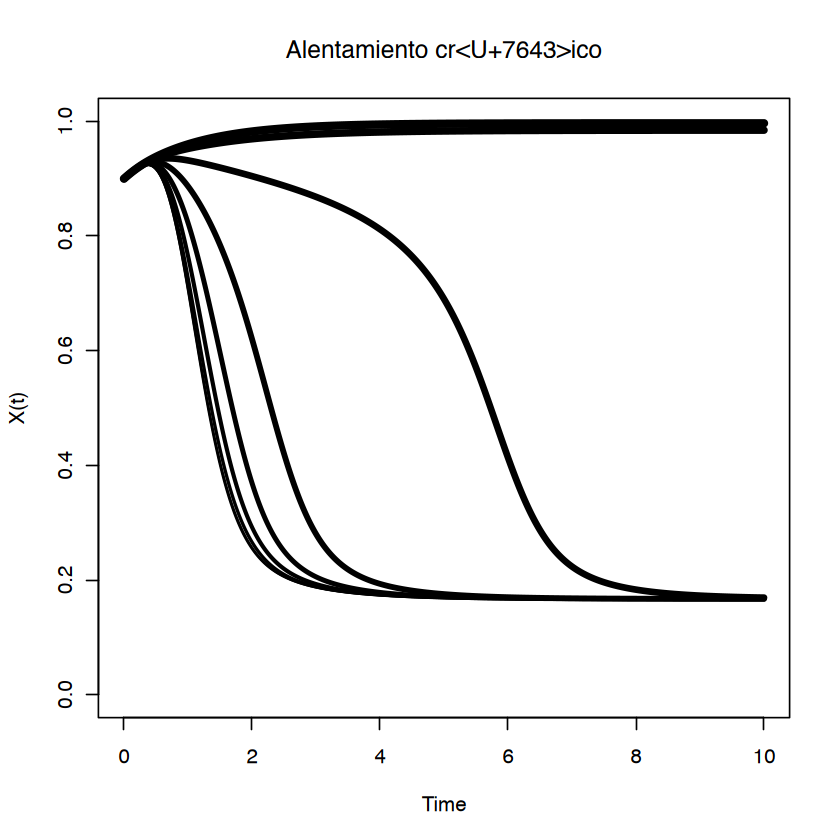

        x         y 
0.5057743 0.6195077 
Unstable point, eigenvalues:  -4.795959 1.204608 
        x         y 
0.9946980 0.1681565 
Stable point, eigenvalues:  -5.989611 -0.9625594 
        x         y 
0.1357302 0.9966187 
Stable point, eigenvalues:  -7.419698 -0.9512533 
Starting at v = 1 with:
        x         y 
0.1357302 0.9966187 


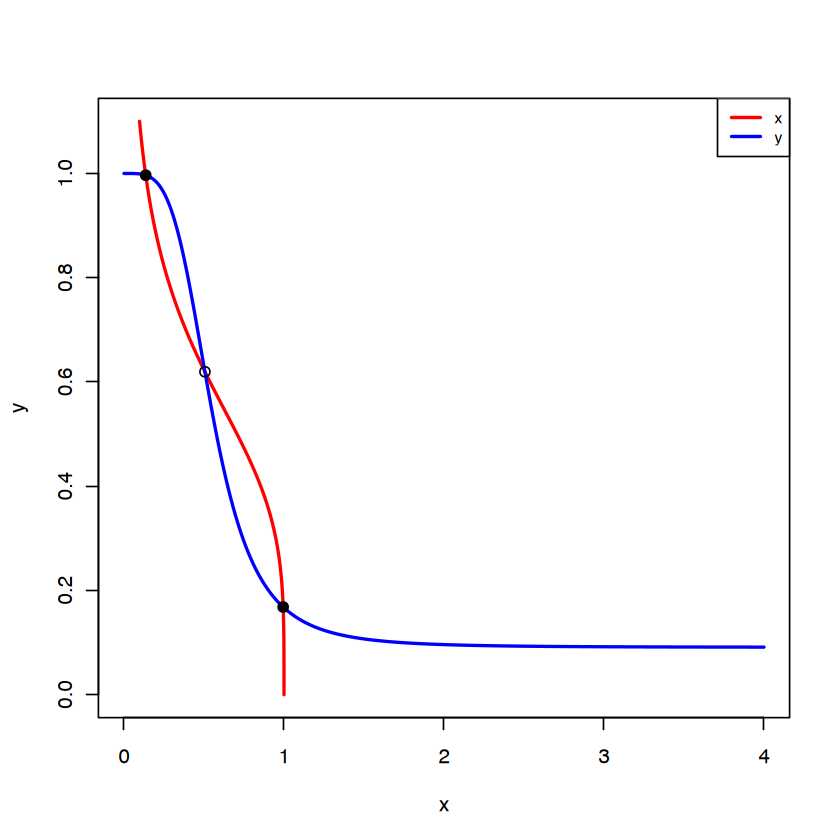

Starting at v = 1 with:
        x         y 
0.9946980 0.1681565 
Final point at v = 1.796859 
If this looks wrong try changing the step size
Starting at v = 1 with:
        x         y 
0.5057743 0.6195077 
Final point at v = 1.796859 
If this looks wrong try changing the step size
Final point at v = 0.8315781 
If this looks wrong try changing the step size


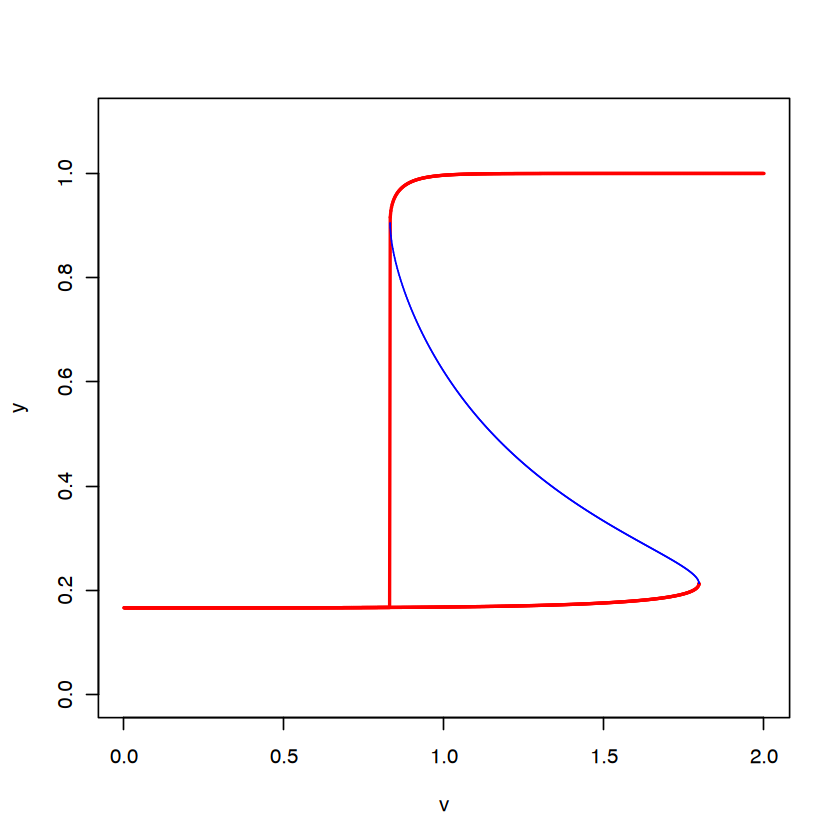

In [1]:
### Practica 2: Anaisis de un sistma de ecuaciones diferenciales acopladas y no lineales:

##. Angeli, D., Ferrell, J. E. & Sontag, E. D. Detection of multistability, bifurcations, and hysteresis in a large class of biological positive-feedback systems. PNAS 101, 1822-7 (2004).

# Borramos todo
#rm(list=ls())

# Instalar la paquetería que necesitamos
library(deSolve)
library(phaseR)

# Declarar los valores de parametros que permanecen constantes
alpha1=1; alpha2=1; beta1=200; beta2=10; gamma1=4; gamma2=4; 
K1=30; K2=1;
#v=1;

Angeli2004 <- function(t, y, parms){  
    #         1      2       3      4       5     6      7   8   9
  #parms=(alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v)
         dX <- parms[1]*(1-y[1])-parms[3]*y[1]*(parms[9]*y[2])^parms[5]/(parms[7]+(parms[9]*y[2])^parms[5]);  
         dY <- parms[2]*(1-y[2])-parms[4]*y[2]*y[1]^parms[6]/(parms[8]+y[1]^parms[6]);
         list(c(dX,dY))
}

# Condiciones iniciales
ini_1 <- c(0,0); ini_2 <- c(0,0.9)

# Tiempo de integración
tspan <- seq(from = 0, to = 10, by = 0.01)

############## PREGUNTA 1: DINAMICA DEL SISTEMA ######################

# parametro de bifurcación - 
for (v in c(0.75, 1, 1.9)){
 
 parms=c(alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v)

# ， integrar!
out1 <- ode(y = ini_1, times = tspan, func = Angeli2004, parms = parms)

plot(out1[,1], out1[,2],type = "l", ylim=c(0,1),col="red", xlab = "Time", ylab = "X(t)", main = paste("v=", toString(v), sep=" "))

#Ahora con la segunda condición inicial
out2 <- ode(y = ini_2, times = tspan, func = Angeli2004, parms = parms)
lines(out2[,1], out2[,2],type = "l", col="blue")
legend=c(paste("I.C.=", toString(ini_1), sep=" "), paste("I.C.=", toString(ini_2), sep=" "))

# Añadamos a este diagrama de espacio fase un campo vectorial
Angeli2004.flowField <- flowField(Angeli2004, xlim = c(0, 1), ylim = c(0, 1), parameters = parms, points = 10, add = FALSE)
Angeli2004.trajectory <- trajectory(Angeli2004, y0 = ini_1, tlim = c(0,10), parameters = parms, col = "blue")
Angeli2004.trajectory <- trajectory(Angeli2004, y0 = ini_2, tlim = c(0,10), parameters = parms, col = "red")
}

############ PREGUNTA 2: Cuencas de atracción ###############

  # paraetro de bifurcación - 
  for (v in c(1, 1.6)){
    parms=c(alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v)
    
    # Añdamos a este diagrama de espacio fase un campo vectorial
    flowField(Angeli2004, xlim = c(0, 1), ylim = c(0, 1), parameters = parms, points = 10, add = FALSE)
    
    # Genera n condiciones iniciales al azar, pero sobre el margen ([x=0,1; y=rand] y vice versa)
    for (ii in seq(1,20,1) ){
      # generate 3 random numbers
      r1=runif(1); r2=runif(1); r3=runif(1);
      
      if (r1<0.5){
      ini = c(as.numeric(r2<0.5), r3)
      } else {
      ini = c(r3, as.numeric(r2<0.5))
      }
      
    trajectory(Angeli2004, y0 = ini, tlim = c(0,10), parameters = parms, col = "blue")
    }
  }



############ PREGUNTA 3: Señales de alerta temprana ###############

LineWidth=1
# parametro de bifurcación - 
for (v in seq(0.2,1,0.1)){
  
  parms=c(alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v)
  
  # ， integrar!
  out <- ode(y = ini_2, times = tspan, func = Angeli2004, parms = parms)
  
  if (v==0.2){
  plot(out[,1], out[,3],type = "l", ylim=c(0,1),col="black", xlab = "Time", ylab = "X(t)", lwd=LineWidth, main="Alentamiento cr癃ico" )
  } else {
  lines(out[,1], out[,3],type = "l", col="black", lwd=LineWidth)
  }
  
  LineWidth=LineWidth+0.5
  
}
  

############## PREGUNTA 4: Diagrama de bifurcación ######################

# Corre el codigo anexo:
source('Grind.r') # puedes hacerlo abriendolo y corriendolo, o ir a la carpeta en la que esta con setwd(..) y luego


# Declarar los valores de parametros que permanecen constantes
alpha1=1; alpha2=1; beta1=200; beta2=10; gamma1=4; gamma2=4; 
K1=30; K2=1;
#v=1;

model <- function(t, state, parms){  
  with(as.list(c(state,parms)), {
    dx = alpha1*(1-x)-beta1*x*(v*y)^gamma1/(K1+(v*y)^gamma1)
    dy = alpha2*(1-y)-beta2*y*x^gamma2/(K2+x^gamma2)
    return(list(c(dx, dy)))
  })
}
  

p <-  c(alpha1=1, alpha2=1, beta1=200, beta2=10, gamma1=4, gamma2=4, K1=30, K2=1, v=1)
s <- c(x=0,y=0)
plane(xmax=4)
mid <- newton(s,plot=T)
low <- newton(c(x=1,y=0),plot=T)
hig <- newton(c(x=0,y=1),plot=T)

continue(state=hig, parms=p, odes=model, x="v", step=0.001, xmin=0, xmax=2,y="y", ymin=0, ymax=1.1) # log="", time=0, positive=TRUE, add=TRUE)
continue(state=low, parms=p, odes=model, x="v", step=0.001, xmin=0, xmax=2,y="y", ymin=0, ymax=1.1, log="", time=0, positive=TRUE, add=TRUE)
continue(state=mid, parms=p, odes=model, x="v", step=0.001, xmin=0, xmax=2,y="y", ymin=0, ymax=1.1, log="", time=0, positive=TRUE, add=TRUE)




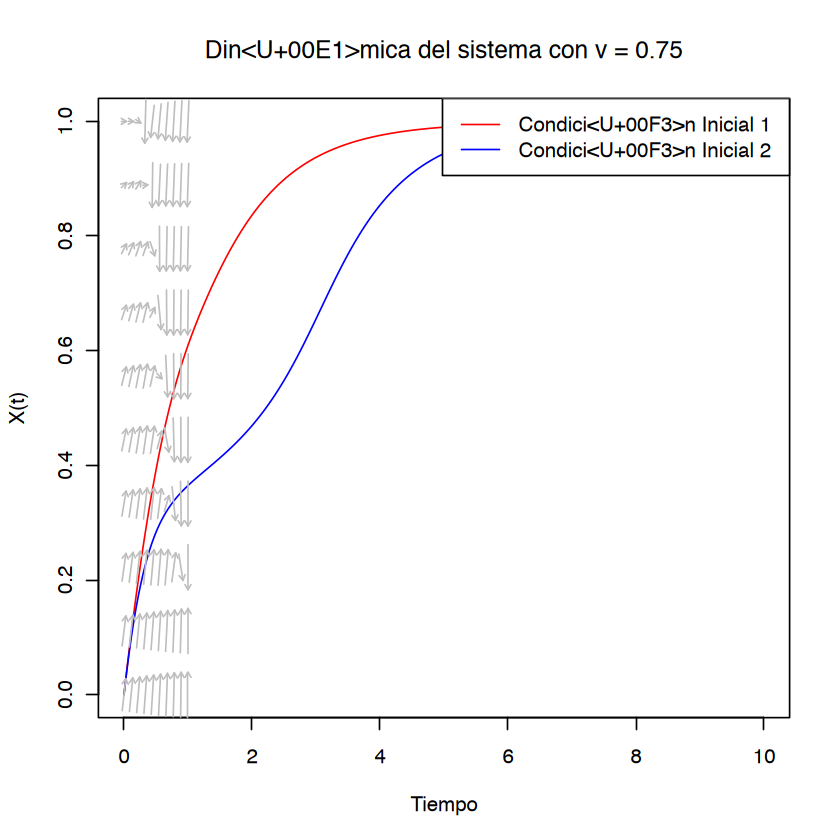

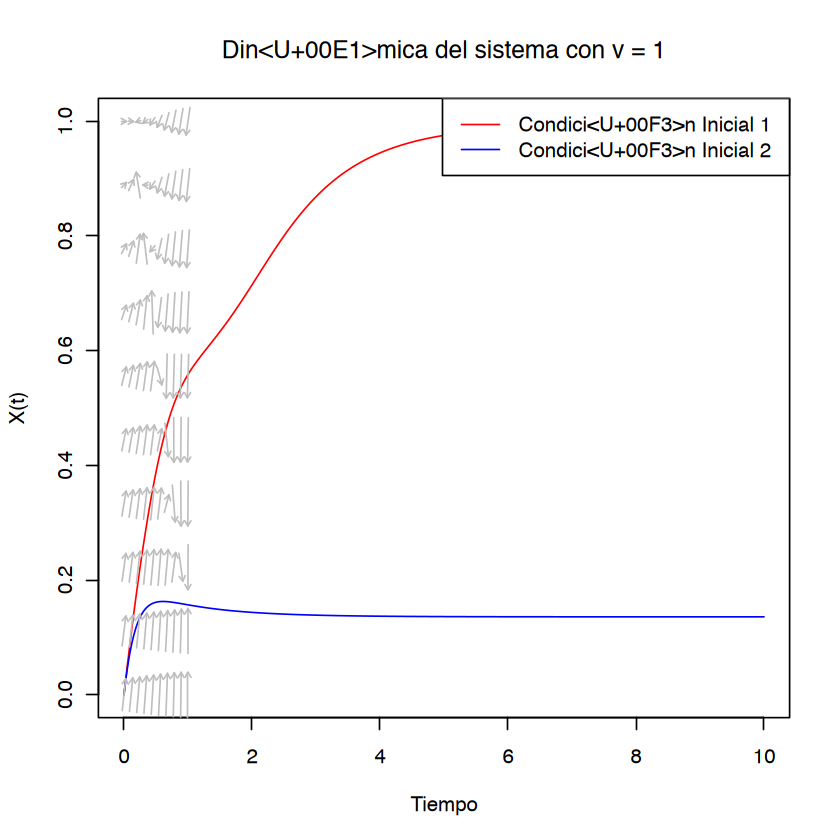

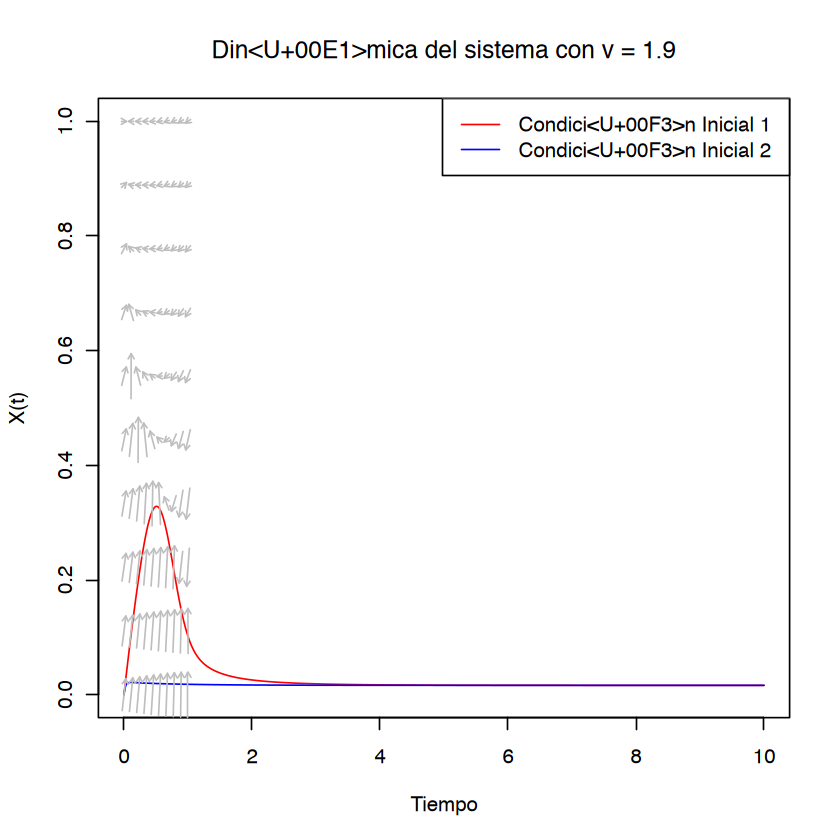

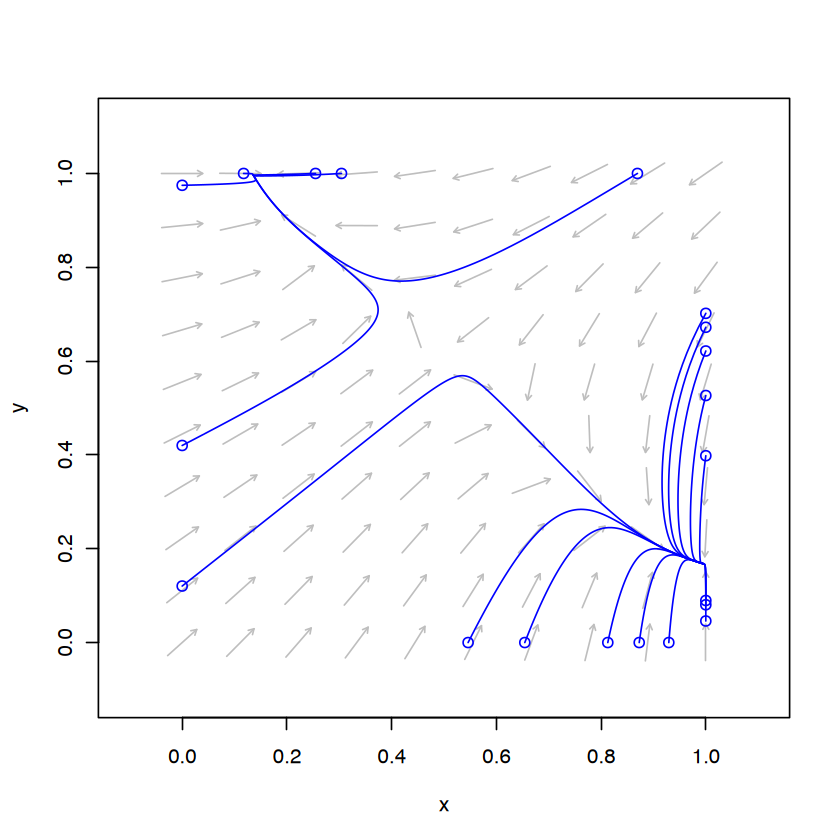

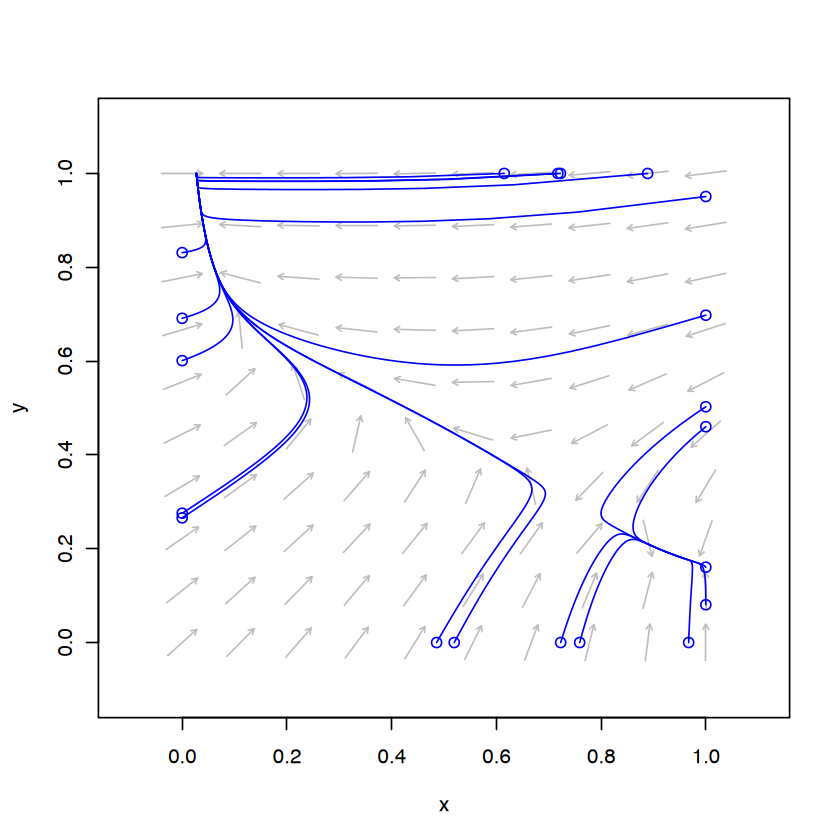

grind.R was sourced


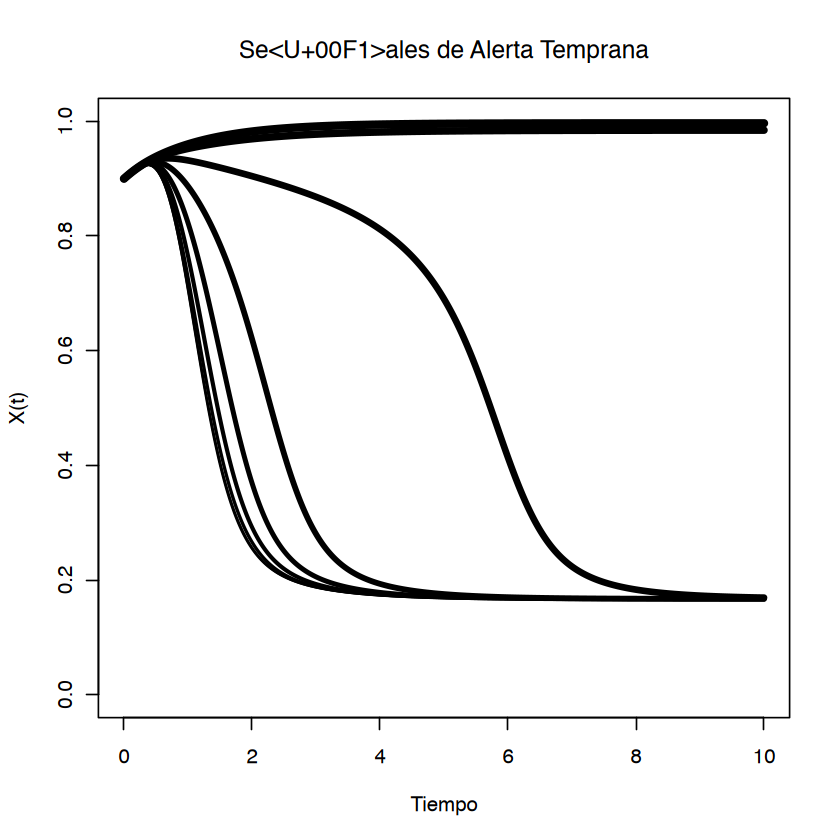

        x         y 
0.5057743 0.6195077 
Unstable point, eigenvalues:  -4.795959 1.204608 
        x         y 
0.9946980 0.1681565 
Stable point, eigenvalues:  -5.989611 -0.9625594 
        x         y 
0.1357302 0.9966187 
Stable point, eigenvalues:  -7.419698 -0.9512533 
Starting at v = 1 with:
        x         y 
0.1357302 0.9966187 


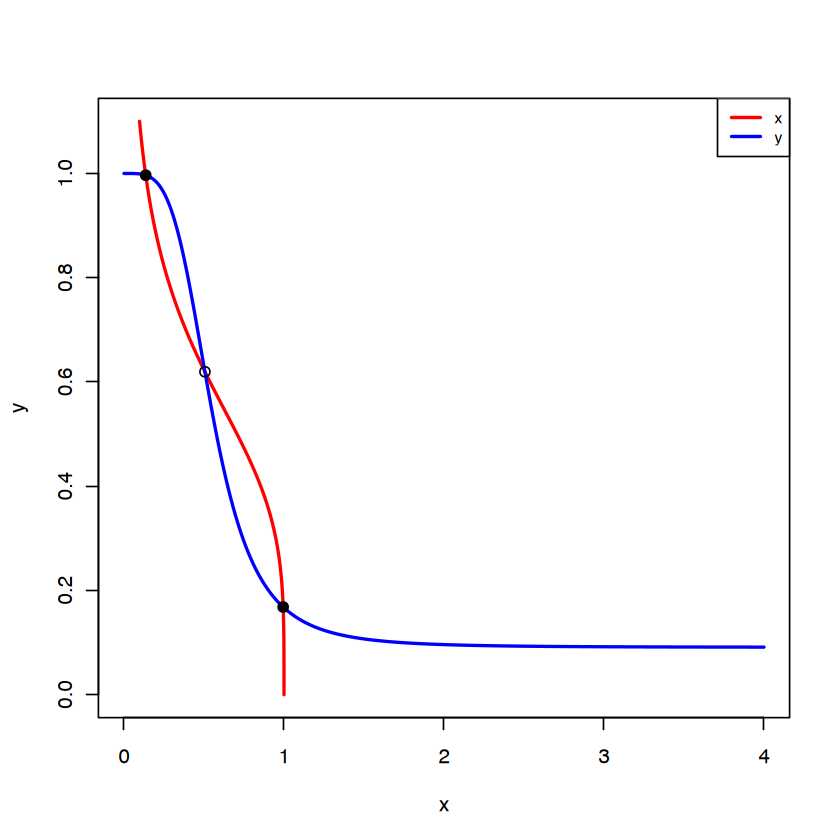

Starting at v = 1 with:
        x         y 
0.9946980 0.1681565 
Final point at v = 1.796859 
If this looks wrong try changing the step size
Starting at v = 1 with:
        x         y 
0.5057743 0.6195077 
Final point at v = 1.796859 
If this looks wrong try changing the step size
Final point at v = 0.8315781 
If this looks wrong try changing the step size


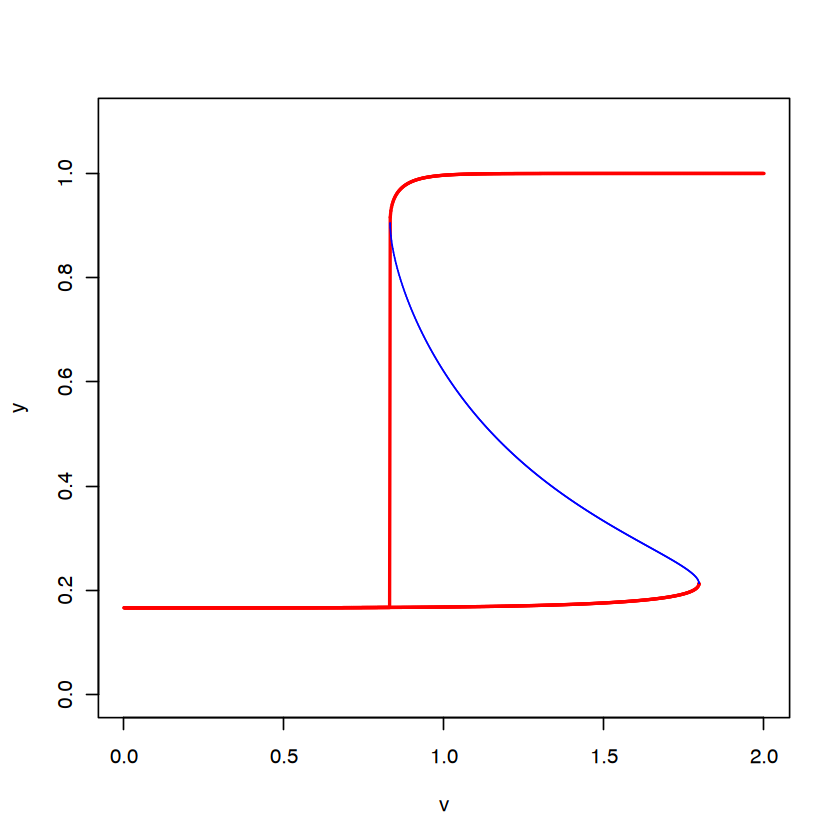

In [2]:
# Limpia el entorno de trabajo
rm(list=ls())

# Instalar la paquetería necesaria (si no está instalada ya)
if (!require("deSolve")) install.packages("deSolve", dependencies=TRUE)
if (!require("phaseR")) install.packages("phaseR", dependencies=TRUE)

library(deSolve)
library(phaseR)

# Definir los valores de parámetros que permanecen constantes
alpha1 <- 1
alpha2 <- 1
beta1 <- 200
beta2 <- 10
gamma1 <- 4
gamma2 <- 4
K1 <- 30
K2 <- 1

# Definir la función del modelo de Angeli et al. (2004)
Angeli2004 <- function(t, y, parms){  
    dX <- parms[1]*(1 - y[1]) - parms[3]*y[1]*(parms[9]*y[2])^parms[5]/(parms[7] + (parms[9]*y[2])^parms[5])
    dY <- parms[2]*(1 - y[2]) - parms[4]*y[2]*y[1]^parms[6]/(parms[8] + y[1]^parms[6])
    list(c(dX, dY))
}

# Definir condiciones iniciales
ini_1 <- c(0, 0)
ini_2 <- c(0, 0.9)

# Tiempo de integración
tspan <- seq(from = 0, to = 10, by = 0.01)

############## PREGUNTA 1: DINÁMICA DEL SISTEMA ######################

# Se probarán distintos valores del parámetro de bifurcación 'v'
for (v in c(0.75, 1, 1.9)){
 
  # Parámetros del sistema
  parms <- c(alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v)

  # Resolver el sistema con la primera condición inicial
  out1 <- ode(y = ini_1, times = tspan, func = Angeli2004, parms = parms)

  # Graficar los resultados para X(t)
  plot(out1[,1], out1[,2], type = "l", ylim=c(0,1), col="red", xlab = "Tiempo", ylab = "X(t)", 
       main = paste("Dinámica del sistema con v =", toString(v)))

  # Resolver el sistema con la segunda condición inicial
  out2 <- ode(y = ini_2, times = tspan, func = Angeli2004, parms = parms)
  
  # Añadir la segunda solución a la gráfica
  lines(out2[,1], out2[,2], type = "l", col="blue")

  # Añadir leyenda para distinguir las condiciones iniciales
  legend("topright", legend = c("Condición Inicial 1", "Condición Inicial 2"), col = c("red", "blue"), lty = 1)
  
  # Añadir el campo vectorial (diagrama de espacio fase)
  flowField(Angeli2004, xlim = c(0, 1), ylim = c(0, 1), parameters = parms, points = 10, add = TRUE)
}

############## PREGUNTA 2: CUENCAS DE ATRACCIÓN ######################

# Para cada valor de 'v', generar el diagrama de fase y ver las cuencas de atracción
for (v in c(1, 1.6)){
  
  parms <- c(alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v)
  
  # Graficar el campo vectorial en el espacio fase
  flowField(Angeli2004, xlim = c(0, 1), ylim = c(0, 1), parameters = parms, points = 10, add = FALSE)
  
  # Generar múltiples condiciones iniciales aleatorias en los márgenes
  for (ii in seq(1, 20, 1)){
    
    r1 <- runif(1); r2 <- runif(1); r3 <- runif(1)
    
    # Generar condiciones iniciales aleatorias en el margen
    if (r1 < 0.5) {
      ini <- c(as.numeric(r2 < 0.5), r3)
    } else {
      ini <- c(r3, as.numeric(r2 < 0.5))
    }
    
    # Graficar las trayectorias de cada condición inicial
    trajectory(Angeli2004, y0 = ini, tlim = c(0, 10), parameters = parms, col = "blue")
  }
}

############## PREGUNTA 3: SEÑALES DE ALERTA TEMPRANA ######################

# Parámetro de bifurcación 'v'
LineWidth <- 1
for (v in seq(0.2, 1, 0.1)){
  
  parms <- c(alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v)
  
  # Integrar el sistema
  out <- ode(y = ini_2, times = tspan, func = Angeli2004, parms = parms)
  
  # Graficar la dinámica del sistema con varios valores de v
  if (v == 0.2) {
    plot(out[,1], out[,3], type = "l", ylim = c(0, 1), col = "black", xlab = "Tiempo", ylab = "X(t)", 
         lwd = LineWidth, main = "Señales de Alerta Temprana")
  } else {
    lines(out[,1], out[,3], type = "l", col = "black", lwd = LineWidth)
  }
  
  # Incrementar el grosor de la línea para los siguientes gráficos
  LineWidth <- LineWidth + 0.5
}

############## PREGUNTA 4: DIAGRAMA DE BIFURCACIÓN ######################

# Fuente externa para generar diagrama de bifurcación
source('Grind.r')

# Definir el modelo para el diagrama de bifurcación
model <- function(t, state, parms){  
  with(as.list(c(state,parms)), {
    dx = alpha1*(1 - x) - beta1*x*(v*y)^gamma1/(K1 + (v*y)^gamma1)
    dy = alpha2*(1 - y) - beta2*y*x^gamma2/(K2 + x^gamma2)
    return(list(c(dx, dy)))
  })
}

# Definir parámetros y estados iniciales
p <-  c(alpha1=1, alpha2=1, beta1=200, beta2=10, gamma1=4, gamma2=4, K1=30, K2=1, v=1)
s <- c(x=0, y=0)

# Crear el plano de fase y graficar puntos fijos y bifurcaciones
plane(xmax = 4)
mid <- newton(s, plot = TRUE)
low <- newton(c(x = 1, y = 0), plot = TRUE)
hig <- newton(c(x = 0, y = 1), plot = TRUE)

# Continuar con el diagrama de bifurcación para los diferentes puntos fijos
continue(state = hig, parms = p, odes = model, x = "v", step = 0.001, xmin = 0, xmax = 2, y = "y", ymin = 0, ymax = 1.1)
continue(state = low, parms = p, odes = model, x = "v", step = 0.001, xmin = 0, xmax = 2, y = "y", ymin = 0, ymax = 1.1, add = TRUE)
continue(state = mid, parms = p, odes = model, x = "v", step = 0.001, xmin = 0, xmax = 2, y = "y", ymin = 0, ymax = 1.1, add = TRUE)
